In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit
from pathlib import Path

prf_path = Path("~/Research/AsTrovello/Input/S4G/PSF").expanduser()
prf_path

PosixPath('/Users/andretrovello/Research/AsTrovello/Input/S4G/PSF')

In [23]:
prf = fits.getdata(prf_path / "IRAC1_col129_row129.fits")

n = prf.shape[0]; cy, cx = n//2, n//2
y, x = np.indices(prf.shape)
r = np.sqrt((x-cx)**2 + (y-cy)**2)

print(n)
print(cy)
print(cx)
print(r)

128
64
64
[[90.50966799 89.80534505 89.10667764 ... 88.41379983 89.10667764
  89.80534505]
 [89.80534505 89.09545443 88.39117603 ... 87.69264507 88.39117603
  89.09545443]
 [89.10667764 88.39117603 87.68124087 ... 86.97700846 87.68124087
  88.39117603]
 ...
 [88.41379983 87.69264507 86.97700846 ... 86.2670273  86.97700846
  87.69264507]
 [89.10667764 88.39117603 87.68124087 ... 86.97700846 87.68124087
  88.39117603]
 [89.80534505 89.09545443 88.39117603 ... 87.69264507 88.39117603
  89.09545443]]


In [22]:
nan_values = np.isnan(prf).sum()
inf_values = np.isinf(prf).sum()
print("NaNs: ", nan_values)
print("Infs: ", inf_values)


NaNs:  0
Infs:  0


/opt/homebrew/Caskroom/miniconda/base/envs/capivara/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniconda/base/envs/capivara/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


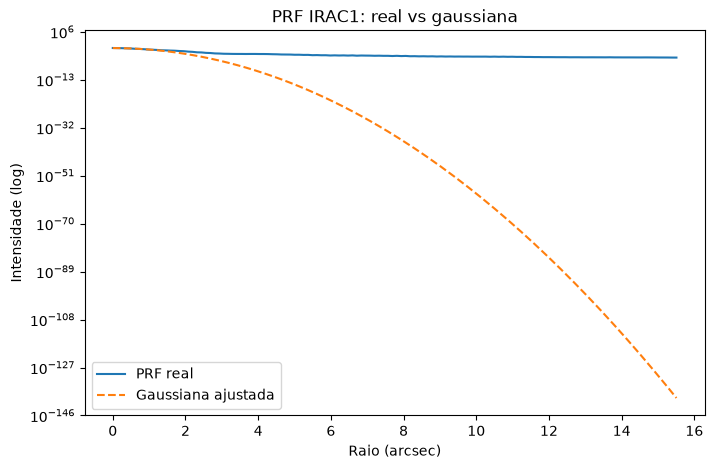

In [27]:
r_bins = np.arange(0, n // 2, 0.5)
profile = np.array([np.median(prf[(r >= rb) & (r < rb + 0.5)]) for rb in r_bins])

# 2. Filtrar NaNs dos primeiros 30 pontos para o ajuste
x_fit = r_bins[:30]
y_fit = profile[:30]
valid_mask = np.isfinite(y_fit)

x_fit = x_fit[valid_mask]
y_fit = y_fit[valid_mask]

# 3. Ajuste Gaussiano
gauss = lambda r, A, sig: A * np.exp(-r**2 / (2 * sig**2))
popt, _ = curve_fit(gauss, x_fit, y_fit, p0=[np.nanmax(y_fit), 5])

# 4. Plotagem (filtrando NaNs do profile para o gráfico não quebrar a linha)
valid_all = np.isfinite(profile)
plt.figure(figsize=(8, 5))
plt.semilogy(r_bins[valid_all] * 0.2442, profile[valid_all], label='PRF real')
plt.semilogy(r_bins * 0.2442, gauss(r_bins, *popt), '--', label='Gaussiana ajustada')
plt.xlabel('Raio (arcsec)')
plt.ylabel('Intensidade (log)')
plt.legend()
plt.title('PRF IRAC1: real vs gaussiana')
plt.show()

In [28]:
# Achar o pixel central do pico
cy, cx = np.unravel_index(np.nanargmax(prf), prf.shape)

# Construir a grade r centrada no pico
y, x = np.indices(prf.shape)
r = np.sqrt((x - cx)**2 + (y - cy)**2)

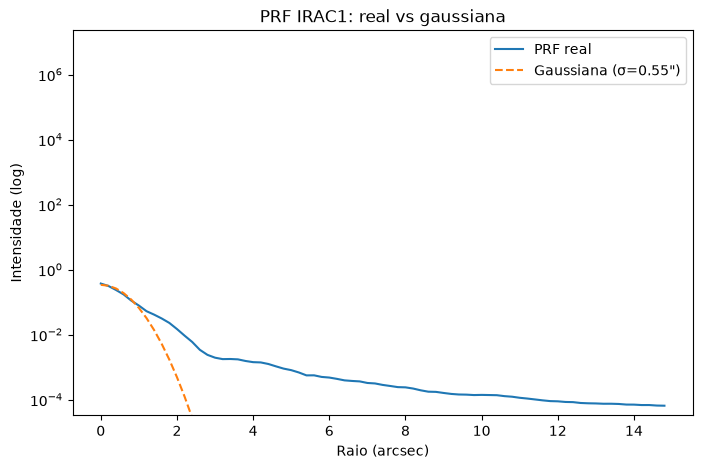

In [31]:
scale = 0.2442  # arcsec/pixel

# Raio em arcsec
r_arcsec = r * scale

# Bins em arcsec (ex: passo de 0.2 arcsec até ~15 arcsec)
r_bins = np.arange(0, 15, 0.2)
bin_width = r_bins[1] - r_bins[0]

# Perfil radial
profile = np.array([
    np.nanmedian(prf[(r_arcsec >= rb) & (r_arcsec < rb + bin_width)])
    for rb in r_bins
])

# Filtrar NaNs e valores não positivos (necessários para escala log e estabilidade)
valid = np.isfinite(profile) & (profile > 0)
x_valid = r_bins[valid]
y_valid = profile[valid]

# Ajuste Gaussiano (com limite até ~3 arcsec para pegar o núcleo)
fit_mask = x_valid < 3.0
x_fit = x_valid[fit_mask]
y_fit = y_valid[fit_mask]

# Modelo gaussiano (FWHM do IRAC 1 é ~1.66 arcsec, logo sigma ~ 0.7 arcsec)
gauss = lambda r, A, sig: A * np.exp(-r**2 / (2 * sig**2))
p0 = [np.max(y_fit), 0.7]

popt, _ = curve_fit(gauss, x_fit, y_fit, p0=p0)

# Gráfico
plt.figure(figsize=(8, 5))
plt.semilogy(x_valid, y_valid, label='PRF real')
plt.semilogy(r_bins, gauss(r_bins, *popt), '--', label=f'Gaussiana (σ={popt[1]:.2f}")')
plt.ylim(bottom=np.min(y_valid[y_valid > 0]) * 0.5)  # Evita o eixo Y ir para 10^-140
plt.xlabel('Raio (arcsec)')
plt.ylabel('Intensidade (log)')
plt.legend()
plt.title('PRF IRAC1: real vs gaussiana')
plt.show()